In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib, warnings, sys

from sklearn.compose import TransformedTargetRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

warnings.filterwarnings('ignore', category=UserWarning)

In [ ]:
from huggingface_hub import notebook_login, hf_hub_download

notebook_login()

In [15]:
sys.path.append("../src")
from data_pipeline import modeling_pipeline

In [5]:
data = pd.read_csv(r'C:\Users\MELIODAS\Desktop\Coding\Machine Learning\Portnet Imputation Prediction\data\processed\cleaned_data.csv')

In [16]:
repo_id = "Meliodas-10/portnet-model"

model_file = hf_hub_download(repo_id=repo_id, filename="portnet_model.pkl")
full_model = joblib.load(model_file)

print("Modèle rechargé depuis Hugging Face !")

Modèle rechargé depuis Hugging Face !


In [17]:
full_model

TransformedTargetRegressor(func=<ufunc 'log1p'>, inverse_func=<ufunc 'expm1'>,
                           regressor=Pipeline(steps=[('preprocessor',
                                                      PortNetDataPreprocessing()),
                                                     ('algorithme',
                                                      RandomForestRegressor(max_depth=15,
                                                                            min_samples_leaf=4,
                                                                            min_samples_split=5,
                                                                            n_estimators=200,
                                                                            n_jobs=-1,
                                                                            random_state=42))]))

In [18]:
X = data.drop(columns=['QTE_IMPUTE'])
y = data['QTE_IMPUTE']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

In [ ]:
# Configuration visuelle
sns.set_theme(style="whitegrid")
plt.rcParams.update({'figure.figsize': (10, 6), 'axes.titlesize': 14})

In [ ]:
y_pred = full_model.predict(X_test)

[_logarithmic_transform] exécuté en 0.062s | Lignes restantes: 666531
[_impute_and_scale] exécuté en 0.054s | Lignes restantes: 666531
[_target_encode] exécuté en 0.125s | Lignes restantes: 666531


# 1- Metrics

In [43]:
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
wmape = np.sum(np.abs(y_test - y_pred)) / np.sum(np.abs(y_test))

print("--- Audit des Performances ---")
print(f"R² (Explication de la variance) : {r2:.4f}")
print(f"MAE (Erreur moyenne absolue)   : {mae:,.2f}")
print(f"RMSE (Pénalité gros écarts)    : {rmse:,.2f}")
print(f"WMAPE (Marge d'erreur relative) : {wmape:.2%}")

--- Audit des Performances ---
R² (Explication de la variance) : 0.9303
MAE (Erreur moyenne absolue)   : 11,339.47
RMSE (Pénalité gros écarts)    : 142,140.21
WMAPE (Marge d'erreur relative) : 19.67%


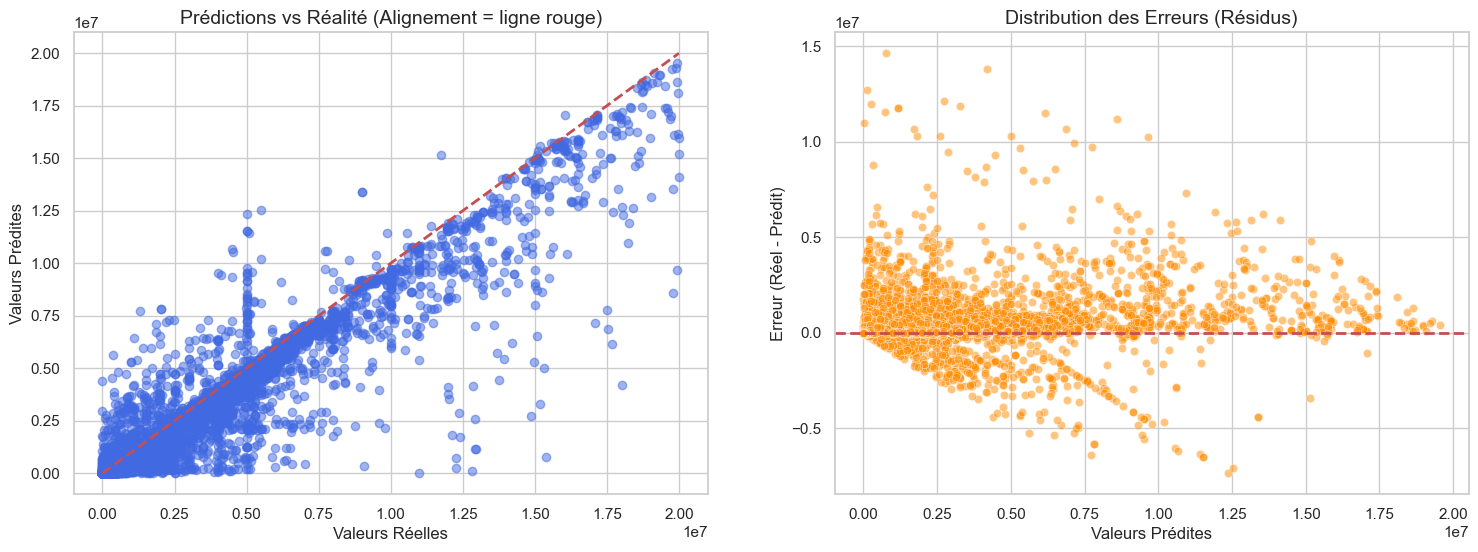

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# 1. Actual vs Predicted
axes[0].scatter(y_test, y_pred, alpha=0.5, color='royalblue')
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
axes[0].set_title("Prédictions vs Réalité (Alignement = ligne rouge)")
axes[0].set_xlabel("Valeurs Réelles")
axes[0].set_ylabel("Valeurs Prédites")

# 2. Analyse des Résidus
residuals = y_test - y_pred
sns.scatterplot(x=y_pred, y=residuals, alpha=0.5, color='darkorange', ax=axes[1])
axes[1].axhline(y=0, color='r', linestyle='--', lw=2)
axes[1].set_title("Distribution des Erreurs (Résidus)")
axes[1].set_xlabel("Valeurs Prédites")
axes[1].set_ylabel("Erreur (Réel - Prédit)")
plt.show()

[_logarithmic_transform] exécuté en 0.004s | Lignes restantes: 1
[_impute_and_scale] exécuté en 0.002s | Lignes restantes: 1
[_target_encode] exécuté en 0.007s | Lignes restantes: 1


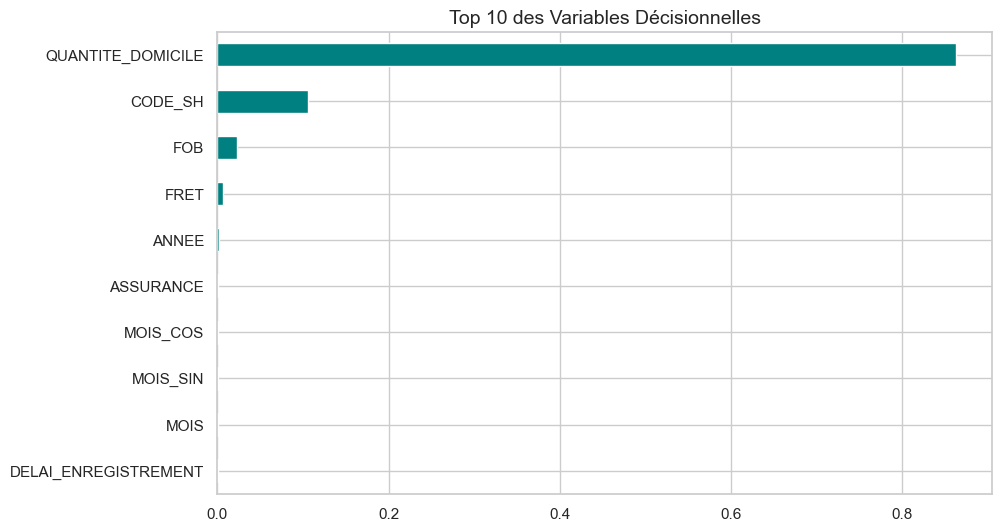

In [ ]:
inner_pipeline = full_model.regressor_
rf_step = inner_pipeline.named_steps['algorithme']

sample_transformed = inner_pipeline.named_steps['preprocessor'].transform(X_test.iloc[[0]])

if hasattr(sample_transformed, 'columns'):
    feature_names = sample_transformed.columns
else:
    feature_names = X_train.columns

# 3. Création et affichage du graphique
importances = pd.Series(rf_step.feature_importances_, index=feature_names)
importances.nlargest(10).sort_values().plot(kind='barh', color='teal')
plt.title("Top 10 des Variables Décisionnelles")
plt.show()

In [45]:
error_df = X_test.copy()
error_df['Valeur_Reelle'] = y_test
error_df['Prediction'] = y_pred
error_df['Erreur_Absolue'] = np.abs(residuals)

seuil_pire_5 = np.percentile(error_df['Erreur_Absolue'], 95)
pires_erreurs = error_df[error_df['Erreur_Absolue'] >= seuil_pire_5]

print(f"\nDossiers critiques isolés pour audit métier : {len(pires_erreurs)}")
display(pires_erreurs.sort_values(by='Erreur_Absolue', ascending=False).head())


Dossiers critiques isolés pour audit métier : 33327


,ANNEE,MOIS,FRET,FOB,ASSURANCE,FRAIS_ACCESSOIRE,CODE_SH,QUANTITE_DOMICILE,DELAI_ENREGISTREMENT,TRIMESTRE,MOIS_SIN,MOIS_COS,A_UNE_ASSURANCE,A_FRAIS_ACCESSOIRE,Valeur_Reelle,Prediction,Erreur_Absolue
2548922,2022,4,1243458.500,18324650.0,0.0000,0.0,2814100000,15398866.0,0,2,8.660254e-01,-0.500000,0,0,15398866.0,7.686648e+05,1.463020e+07
1259157,2021,5,61463.250,7503126.0,7682.9040,0.0,2710129100,18077424.0,0,2,5.000000e-01,-0.866025,1,0,18020098.0,4.209218e+06,1.381088e+07
2544236,2023,6,45050.000,11262500.0,5631.2500,0.0,2710129190,13250000.0,0,2,1.224647e-16,-1.000000,1,0,12836575.0,1.301437e+05,1.270643e+07
2114748,2017,6,220320.000,7302557.0,165.2400,0.0,2710129100,16265749.0,0,2,1.224647e-16,-1.000000,1,0,14877977.0,2.744044e+06,1.213393e+07
1886892,2023,5,42942.977,10735744.0,5367.8726,0.0,2710129190,12630287.0,0,2,5.000000e-01,-0.866025,1,0,12258480.0,2.589225e+05,1.199956e+07
